# TALLER B4-T1 ? Notebook de Presentaci?n Final

**Dise?o de Redes Confiables: Justicia e Incertidumbre**  
**Dataset:** Home Credit Default Risk

Este notebook es el entregable final de presentaci?n. No define funciones, no lanza Keras Tuner y no reentrena modelos. Su papel es cargar artefactos ya generados y construir una narrativa trazable del sistema:

- `src/`: contrato de preprocesado, capa custom, loss FAIR, modelo e incertidumbre.
- `artifacts/preprocessing.joblib` y `artifacts/processed_data.npz`: transformaciones y splits congelados.
- Modelos `.keras`: checkpoints ya entrenados.
- `artifacts/pareto_data.csv`: frontera de compromiso AUC/equidad.
- `artifacts/results_table.csv`: comparaci?n final base vs. FAIR.
- Outputs de incertidumbre exportados desde `notebooks/03_uncertainty.ipynb`.

## 0. Configuraci?n y carga de artefactos

La ejecuci?n parte de artefactos persistidos. Si el entorno no tiene Keras instalado, el notebook sigue mostrando tablas y figuras; en un entorno con `requirements.txt` completo tambi?n carga los checkpoints `.keras` para inspecci?n.

In [1]:
from pathlib import Path
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image as NotebookImage

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.6f}".format)
sns.set_theme(style="whitegrid", context="notebook")

REPO_ROOT = Path.cwd().resolve()
ARTIFACTS = REPO_ROOT / "artifacts"
SRC = REPO_ROOT / "src"

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src.data as data_module

preprocessing = joblib.load(ARTIFACTS / "preprocessing.joblib")
processed = np.load(ARTIFACTS / "processed_data.npz")
pareto_df = pd.read_csv(ARTIFACTS / "pareto_data.csv")
results_df = pd.read_csv(ARTIFACTS / "results_table.csv")

feature_names = preprocessing["feature_names"]
scalers = preprocessing["scalers"]

X_custom_train = processed["X_custom_train"]
X_custom_val = processed["X_custom_val"]
X_custom_test = processed["X_custom_test"]
X_dense_train = processed["X_dense_train"]
X_dense_val = processed["X_dense_val"]
X_dense_test = processed["X_dense_test"]
y_train = processed["y_train"]
y_val = processed["y_val"]
y_test = processed["y_test"]
s_train = processed["s_train"]
s_val = processed["s_val"]
s_test = processed["s_test"]

artifact_paths = [
    SRC / "data.py",
    SRC / "layers.py",
    SRC / "losses.py",
    SRC / "model.py",
    SRC / "uncertainty.py",
    ARTIFACTS / "preprocessing.joblib",
    ARTIFACTS / "processed_data.npz",
    ARTIFACTS / "base_model.keras",
    ARTIFACTS / "fair_model.keras",
    ARTIFACTS / "best_model.keras",
    ARTIFACTS / "pareto_data.csv",
    ARTIFACTS / "results_table.csv",
    ARTIFACTS / "loss_curves.png",
    ARTIFACTS / "uncertainty_distribution.png",
]

artifact_status = pd.DataFrame({
    "artefacto": [str(p.relative_to(REPO_ROOT)) for p in artifact_paths],
    "existe": [p.exists() for p in artifact_paths],
    "tamano_kb": [round(p.stat().st_size / 1024, 1) if p.exists() else np.nan for p in artifact_paths],
})
display(artifact_status)

C:\Users\diego\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


,artefacto,existe,tamano_kb
0,src\data.py,True,12.300000
1,src\layers.py,True,3.600000
2,src\losses.py,True,5.600000
3,src\model.py,True,5.000000
4,src\uncertainty.py,True,2.500000
5,artifacts\preprocessing.joblib,True,1.300000
6,artifacts\processed_data.npz,True,10467.000000
7,artifacts\base_model.keras,True,45.100000
8,artifacts\fair_model.keras,True,45.100000
9,artifacts\best_model.keras,True,37.900000


In [2]:
model_rows = []
base_model = None
fair_model = None
best_model = None
keras_load_status = "pendiente"

try:
    import keras
    from src.layers import DebtRatioCustomLayer
    from src.losses import make_fair_loss
    from src.model import FairAUC, FairAccuracy, fair_pearson_sq

    base_model = keras.models.load_model(ARTIFACTS / "base_model.keras", compile=False)
    fair_model = keras.models.load_model(ARTIFACTS / "fair_model.keras", compile=False)
    best_model = keras.models.load_model(ARTIFACTS / "best_model.keras", compile=False)
    keras_load_status = "checkpoints .keras cargados con Keras"

    for name, model in [("base_model.keras", base_model), ("fair_model.keras", fair_model), ("best_model.keras", best_model)]:
        model_rows.append({
            "modelo": name,
            "estado": "cargado",
            "input_shape": str(model.input_shape),
            "output_shape": str(model.output_shape),
            "parametros": model.count_params(),
        })
except Exception:
    keras_load_status = "checkpoints .keras detectados; inspecci?n de arquitectura omitida porque Keras no est? disponible en este kernel"
    for name in ["base_model.keras", "fair_model.keras", "best_model.keras"]:
        path_model = ARTIFACTS / name
        model_rows.append({
            "modelo": name,
            "estado": "presente en disco" if path_model.exists() else "no encontrado",
            "input_shape": "requiere Keras",
            "output_shape": "requiere Keras",
            "parametros": np.nan,
        })

print(keras_load_status)
display(pd.DataFrame(model_rows))

checkpoints .keras detectados; inspecci?n de arquitectura omitida porque Keras no est? disponible en este kernel


,modelo,estado,input_shape,output_shape,parametros
0,base_model.keras,presente en disco,requiere Keras,requiere Keras,NaN
1,fair_model.keras,presente en disco,requiere Keras,requiere Keras,NaN
2,best_model.keras,presente en disco,requiere Keras,requiere Keras,NaN


## 1. Contexto del problema y variables

El problema es una clasificaci?n binaria de riesgo de cr?dito. La etiqueta `TARGET` indica si el cliente tuvo dificultades de pago (`1`) o pag? correctamente (`0`). La variable sensible auditada es `CODE_GENDER`, codificada en el pipeline como `s=1` para hombres y `s=0` para mujeres o `XNA`.

La m?trica principal es AUC porque la clase positiva est? fuertemente desbalanceada: una accuracy alta puede ser trivial si casi todos los clientes se clasifican como no default.

In [3]:
split_summary = pd.DataFrame([
    {"split": "train", "n": len(y_train), "default_rate": y_train.mean(), "sensible_s1_rate": s_train.mean(), "X_custom": X_custom_train.shape, "X_dense": X_dense_train.shape},
    {"split": "val", "n": len(y_val), "default_rate": y_val.mean(), "sensible_s1_rate": s_val.mean(), "X_custom": X_custom_val.shape, "X_dense": X_dense_val.shape},
    {"split": "test", "n": len(y_test), "default_rate": y_test.mean(), "sensible_s1_rate": s_test.mean(), "X_custom": X_custom_test.shape, "X_dense": X_dense_test.shape},
])

variable_catalog = pd.DataFrame([
    {"rol": "target", "variable": data_module.TARGET_COL, "tratamiento": "etiqueta binaria"},
    {"rol": "sensible", "variable": data_module.SENSITIVE_COL, "tratamiento": "s viaja fuera de X; se usa en FAIR loss y auditor?a"},
    {"rol": "canal custom", "variable": ", ".join(feature_names["custom"]), "tratamiento": "crudas imputadas para ratio de endeudamiento"},
    {"rol": "canal denso", "variable": ", ".join(feature_names["dense"]), "tratamiento": "monetaria log+robust, edad estandarizada, EXT_SOURCE imputadas, flags"},
])

display(split_summary)
display(variable_catalog)

,split,n,default_rate,sensible_s1_rate,X_custom,X_dense
0,train,215257,0.080727,0.342070,"(215257, 2)","(215257, 8)"
1,val,46127,0.080734,0.340972,"(46127, 2)","(46127, 8)"
2,test,46127,0.080734,0.340321,"(46127, 2)","(46127, 8)"


,rol,variable,tratamiento
0,target,TARGET,etiqueta binaria
1,sensible,CODE_GENDER,s viaja fuera de X; se usa en FAIR loss y audi...
2,canal custom,"AMT_CREDIT, AMT_INCOME_TOTAL",crudas imputadas para ratio de endeudamiento
3,canal denso,"AMT_ANNUITY, AGE, EXT_SOURCE_1, EXT_SOURCE_2, ...","monetaria log+robust, edad estandarizada, EXT_..."


## 2. Routing de features y disciplina anti-fuga

El modelo usa dos entradas funcionales:

- **Canal custom:** `AMT_CREDIT` y `AMT_INCOME_TOTAL` en crudo, solo imputadas. No se escalan porque la capa custom necesita preservar la interpretaci?n del cociente econ?mico.
- **Canal denso:** `AMT_ANNUITY`, `AGE`, `EXT_SOURCE_1/2/3` y flags de imputaci?n. Aqu? s? se aplican transformaciones heterog?neas seg?n la naturaleza de cada variable.

La disciplina anti-fuga queda fijada en `src/data.py`: medianas, `RobustScaler`, `StandardScaler` y calibraciones se ajustan solo en train; validaci?n y test reciben transformaciones ya congeladas.

In [4]:
routing_rows = []
for idx, col in enumerate(feature_names["custom"]):
    routing_rows.append({"canal": "custom", "posicion": idx, "feature": col, "transformacion": "imputaci?n train; sin escalado"})
for idx, col in enumerate(feature_names["dense"]):
    if col == "AMT_ANNUITY":
        treatment = "log1p + RobustScaler ajustado en train"
    elif col == "AGE":
        treatment = "derivada de DAYS_BIRTH + StandardScaler train"
    elif col.startswith("EXT_SOURCE"):
        treatment = "imputaci?n con mediana train; sin escalado"
    elif col.startswith("is_imputed"):
        treatment = "flag determinista de missingness; sin escalado"
    else:
        treatment = "feature densa"
    routing_rows.append({"canal": "dense", "posicion": idx, "feature": col, "transformacion": treatment})

routing_df = pd.DataFrame(routing_rows)
display(routing_df)

anti_leakage = pd.DataFrame([
    {"objeto": "medianas de imputaci?n", "ajuste": "solo train", "aplicaci?n": "train/val/test"},
    {"objeto": "RobustScaler de AMT_ANNUITY", "ajuste": "solo train sobre log1p", "aplicaci?n": "train/val/test"},
    {"objeto": "StandardScaler de AGE", "ajuste": "solo train", "aplicaci?n": "train/val/test"},
    {"objeto": "k del ratio", "ajuste": "percentil 95 solo en train", "aplicaci?n": "capa custom en todos los splits"},
    {"objeto": "flags de missingness", "ajuste": "no hay estad?stico agregado", "aplicaci?n": "isna() por fila"},
])
display(anti_leakage)

,canal,posicion,feature,transformacion
0,custom,0,AMT_CREDIT,imputaci?n train; sin escalado
1,custom,1,AMT_INCOME_TOTAL,imputaci?n train; sin escalado
2,dense,0,AMT_ANNUITY,log1p + RobustScaler ajustado en train
3,dense,1,AGE,derivada de DAYS_BIRTH + StandardScaler train
4,dense,2,EXT_SOURCE_1,imputaci?n con mediana train; sin escalado
5,dense,3,EXT_SOURCE_2,imputaci?n con mediana train; sin escalado
6,dense,4,EXT_SOURCE_3,imputaci?n con mediana train; sin escalado
7,dense,5,is_imputed_EXT_SOURCE_1,flag determinista de missingness; sin escalado
8,dense,6,is_imputed_EXT_SOURCE_2,flag determinista de missingness; sin escalado
9,dense,7,is_imputed_EXT_SOURCE_3,flag determinista de missingness; sin escalado


,objeto,ajuste,aplicaci?n
0,medianas de imputaci?n,solo train,train/val/test
1,RobustScaler de AMT_ANNUITY,solo train sobre log1p,train/val/test
2,StandardScaler de AGE,solo train,train/val/test
3,k del ratio,percentil 95 solo en train,capa custom en todos los splits
4,flags de missingness,no hay estad?stico agregado,isna() por fila


## 3. Capa customizada: ratio `AMT_CREDIT / AMT_INCOME_TOTAL`

La capa `DebtRatioCustomLayer` implementa una feature estructural interpretable:

\[
ratio = \frac{AMT\_CREDIT}{AMT\_INCOME\_TOTAL + \epsilon}
\]

Como el ratio tiene cola derecha larga, no se hace un `clip` duro. Se aplica una saturaci?n suave y diferenciable:

\[
ratio\_sat = \tanh\left(\frac{ratio}{k}\right)
\]

El par?metro `k` no se entrena. Se calibra como el percentil 95 del ratio en train. As?, `ratio = k` se transforma en `tanh(1) ? 0.7616`: la zona com?n conserva resoluci?n y la cola extrema queda comprimida.

k_ratio = p95 train = 9.1453
tanh(1) = 0.7616


,ratio
0.010000,0.594300
0.250000,2.018667
0.500000,3.265067
0.750000,5.161600
0.950000,9.145263
0.990000,13.043478


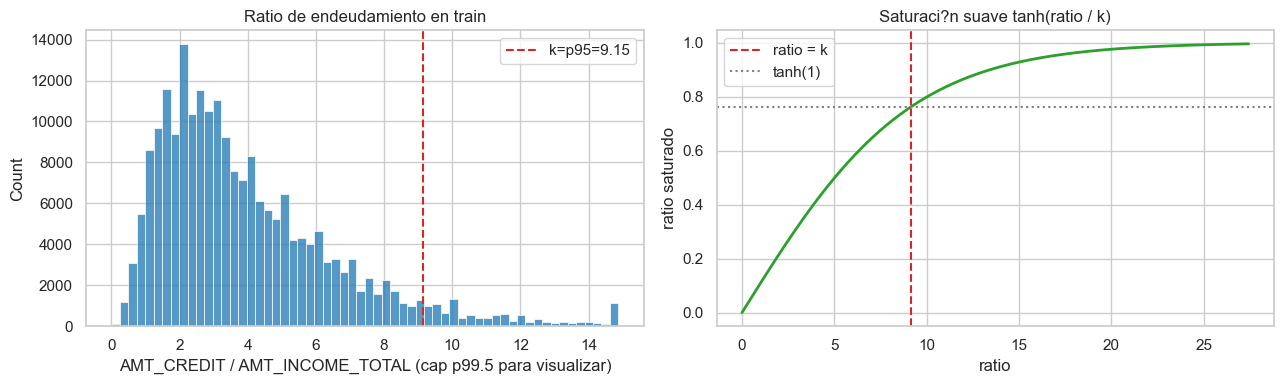

In [5]:
ratio_train = X_custom_train[:, 0] / (X_custom_train[:, 1] + 1e-6)
k_ratio = float(np.percentile(ratio_train, 95))
ratio_quantiles = pd.Series(ratio_train).quantile([0.01, 0.25, 0.5, 0.75, 0.95, 0.99]).rename("ratio")

print(f"k_ratio = p95 train = {k_ratio:.4f}")
print(f"tanh(1) = {np.tanh(1.0):.4f}")
display(ratio_quantiles.to_frame())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_cap = np.percentile(ratio_train, 99.5)
sns.histplot(np.clip(ratio_train, 0, plot_cap), bins=60, ax=axes[0], color="tab:blue")
axes[0].axvline(k_ratio, color="tab:red", linestyle="--", label=f"k=p95={k_ratio:.2f}")
axes[0].set_title("Ratio de endeudamiento en train")
axes[0].set_xlabel("AMT_CREDIT / AMT_INCOME_TOTAL (cap p99.5 para visualizar)")
axes[0].legend()

x = np.linspace(0, 3 * k_ratio, 400)
axes[1].plot(x, np.tanh(x / k_ratio), color="tab:green", linewidth=2)
axes[1].axvline(k_ratio, color="tab:red", linestyle="--", label="ratio = k")
axes[1].axhline(np.tanh(1.0), color="gray", linestyle=":", label="tanh(1)")
axes[1].set_title("Saturaci?n suave tanh(ratio / k)")
axes[1].set_xlabel("ratio")
axes[1].set_ylabel("ratio saturado")
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. FAIR loss: formulaci?n y compromiso AUC/equidad

La loss FAIR combina rendimiento predictivo y una penalizaci?n de dependencia entre la predicci?n `?` y la variable sensible `s`:

\[
Loss = BCE(y, \hat{y})
+ \lambda_{pearson}\rho(\hat{y}, s)^2
+ \lambda_{spearman}\rho_{spearman\_soft}(\hat{y}, s)^2
\]

La idea operativa es simple: mantener AUC competitivo y reducir la dependencia estad?stica de la salida frente a `CODE_GENDER`. En los artefactos de Pareto de este proyecto, el eje de equidad persistido es `val_pearson_sq`; valores menores significan menor dependencia lineal residual.

In [6]:
fair_loss_terms = pd.DataFrame([
    {"termino": "BCE(y, y_hat)", "papel": "aprendizaje predictivo del default", "direccion deseada": "menor"},
    {"termino": "lambda_pearson * Pearson(y_hat, s)^2", "papel": "penaliza dependencia lineal con la variable sensible", "direccion deseada": "hacia 0"},
    {"termino": "lambda_spearman * Spearman_soft(y_hat, s)^2", "papel": "penaliza dependencia mon?tona aproximada", "direccion deseada": "hacia 0"},
    {"termino": "AUC", "papel": "m?trica de selecci?n/evaluaci?n por desbalanceo", "direccion deseada": "mayor"},
])
display(fair_loss_terms)

,termino,papel,direccion deseada
0,"BCE(y, y_hat)",aprendizaje predictivo del default,menor
1,"lambda_pearson * Pearson(y_hat, s)^2",penaliza dependencia lineal con la variable se...,hacia 0
2,"lambda_spearman * Spearman_soft(y_hat, s)^2",penaliza dependencia mon?tona aproximada,hacia 0
3,AUC,m?trica de selecci?n/evaluaci?n por desbalanceo,mayor


## 5. Curva de Pareto desde `pareto_data.csv` **[ENTREGABLE]**

Cada punto corresponde a un entrenamiento con la arquitectura fija y un valor distinto de `lambda_fair`. El compromiso se lee como una frontera: movernos hacia menor dependencia suele costar AUC.

,lambda_fair,val_auc,val_pearson_sq,val_pearson_abs
0,0.000000,0.723529,0.035441,0.188258
1,2.000000,0.707006,0.032963,0.181557
2,10.000000,0.621417,0.031064,0.176251
3,25.000000,0.574299,0.029023,0.170360
4,50.000000,0.552166,0.028837,0.169815


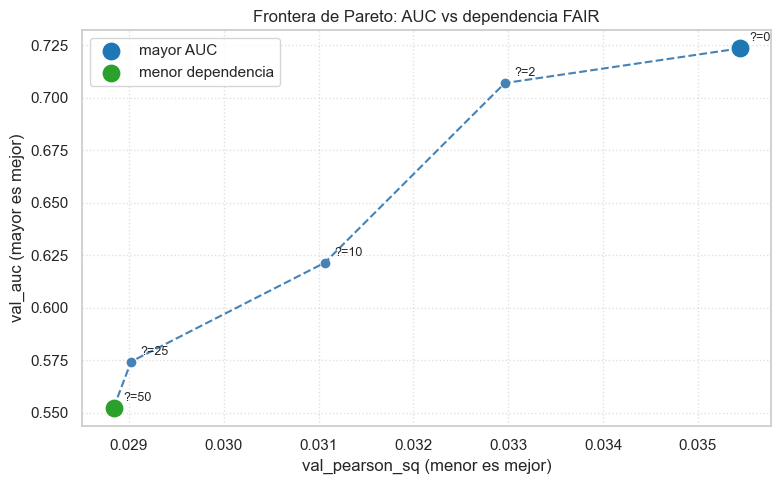

In [7]:
pareto_plot = pareto_df.sort_values("lambda_fair").reset_index(drop=True).copy()
pareto_plot["val_pearson_abs"] = np.sqrt(pareto_plot["val_pearson_sq"])
display(pareto_plot)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pareto_plot["val_pearson_sq"], pareto_plot["val_auc"], marker="o", linestyle="--", color="steelblue", linewidth=1.5)

for _, row in pareto_plot.iterrows():
    ax.annotate(
        f"?={row['lambda_fair']:.0f}",
        (row["val_pearson_sq"], row["val_auc"]),
        textcoords="offset points",
        xytext=(7, 5),
        fontsize=9,
    )

idx_auc = pareto_plot["val_auc"].idxmax()
idx_fair = pareto_plot["val_pearson_sq"].idxmin()
ax.scatter(pareto_plot.loc[idx_auc, "val_pearson_sq"], pareto_plot.loc[idx_auc, "val_auc"], s=140, color="tab:blue", label="mayor AUC", zorder=3)
ax.scatter(pareto_plot.loc[idx_fair, "val_pearson_sq"], pareto_plot.loc[idx_fair, "val_auc"], s=140, color="tab:green", label="menor dependencia", zorder=3)

ax.set_title("Frontera de Pareto: AUC vs dependencia FAIR")
ax.set_xlabel("val_pearson_sq (menor es mejor)")
ax.set_ylabel("val_auc (mayor es mejor)")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Tabla comparativa base vs. mejor FAIR desde `results_table.csv` **[ENTREGABLE]**

La tabla final se calcula en test, que no participa ni en el ajuste de preprocesado ni en la selecci?n de hiperpar?metros. `rho2_Pearson` resume la dependencia residual entre la predicci?n y `CODE_GENDER`: cuanto menor, mejor desde el criterio FAIR usado aqu?.

In [8]:
comparison = results_df.copy()
display(comparison)

base_row = comparison.iloc[0]
fair_row = comparison.iloc[-1]
summary_delta = pd.DataFrame([
    {"metrica": "AUC", "base": base_row["AUC"], "fair": fair_row["AUC"], "delta_fair_minus_base": fair_row["AUC"] - base_row["AUC"]},
    {"metrica": "Accuracy", "base": base_row["Accuracy"], "fair": fair_row["Accuracy"], "delta_fair_minus_base": fair_row["Accuracy"] - base_row["Accuracy"]},
    {"metrica": "rho2_Pearson", "base": base_row["rho2_Pearson"], "fair": fair_row["rho2_Pearson"], "delta_fair_minus_base": fair_row["rho2_Pearson"] - base_row["rho2_Pearson"]},
])
display(summary_delta)

auc_cost = base_row["AUC"] - fair_row["AUC"]
fairness_gain = base_row["rho2_Pearson"] - fair_row["rho2_Pearson"]
print(f"Coste AUC del modelo FAIR frente al base: {auc_cost:.4f}")
print(f"Reducci?n de rho2_Pearson frente al base: {fairness_gain:.6f}")

,modelo,AUC,Accuracy,rho_Pearson,rho2_Pearson
0,base (lambda=0),0.720500,0.919300,0.036869,0.001359
1,fair (lambda=0),0.705400,0.919300,0.002065,0.000004


,metrica,base,fair,delta_fair_minus_base
0,AUC,0.720500,0.705400,-0.015100
1,Accuracy,0.919300,0.919300,0.000000
2,rho2_Pearson,0.001359,0.000004,-0.001355


Coste AUC del modelo FAIR frente al base: 0.0151
Reducci?n de rho2_Pearson frente al base: 0.001355


## 7. Curvas de convergencia de los entrenamientos finales **[ENTREGABLE]**

Las curvas se consumen desde `artifacts/loss_curves.png`, generado por `notebooks/02_model.ipynb` al entrenar los modelos finales. Aqu? solo se visualiza el artefacto persistido.

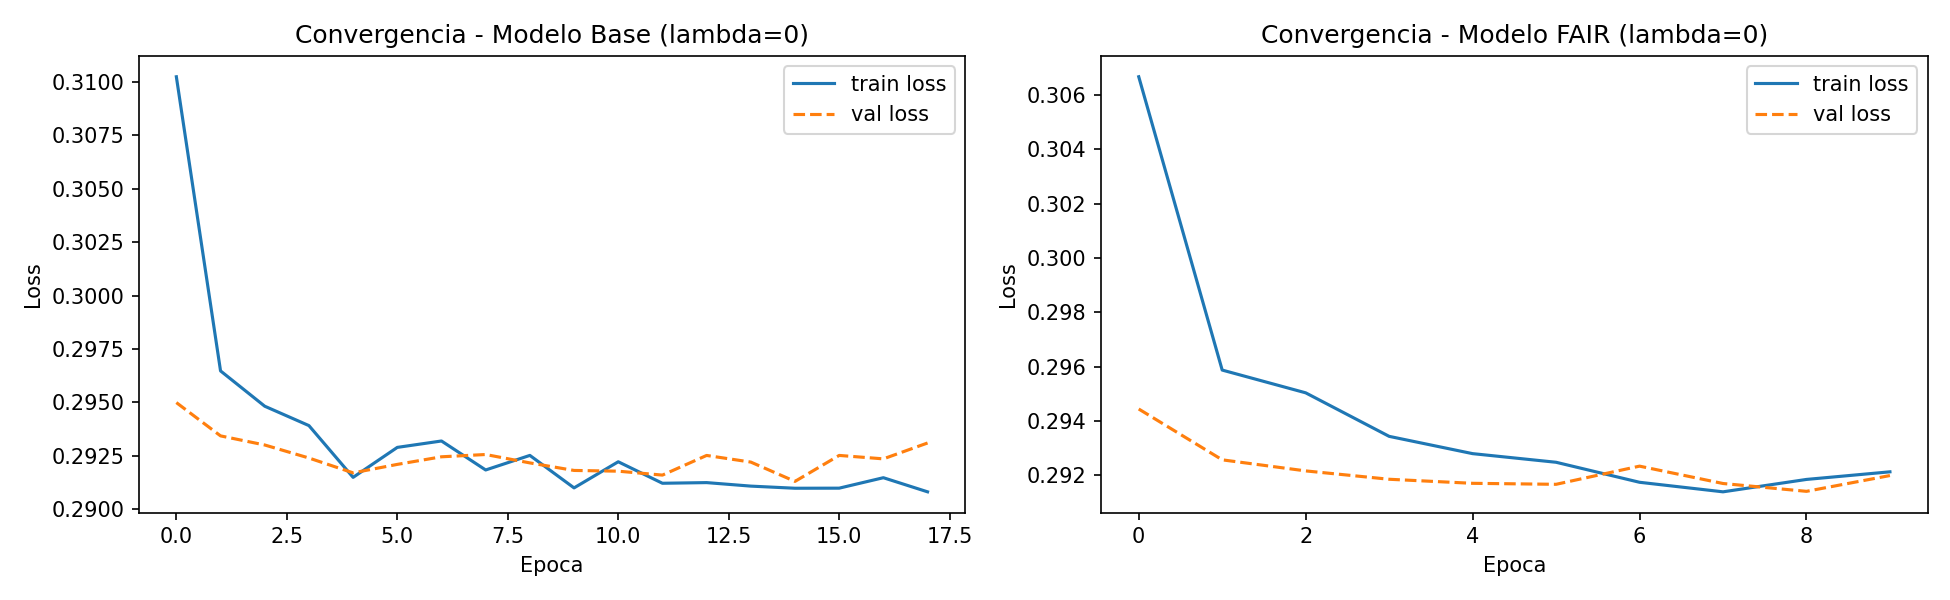

In [9]:
loss_curves_path = ARTIFACTS / "loss_curves.png"
if loss_curves_path.exists():
    display(NotebookImage(filename=str(loss_curves_path)))
else:
    print(f"No se encontr? {loss_curves_path}")

## 8. An?lisis de incertidumbre y distribuci?n por clase **[ENTREGABLE]**

El estimador de incertidumbre se entrena en `notebooks/03_uncertainty.ipynb` para aproximar el error absoluto esperado del clasificador principal. El objetivo de esta secci?n no es reentrenarlo, sino consumir sus salidas: curva de convergencia del auditor y distribuci?n de incertidumbre por clase real.

Una separaci?n visible entre `Buen pagador` y `Mal pagador` indica que el sistema no solo predice riesgo, sino que tambi?n identifica regiones donde espera cometer errores mayores.

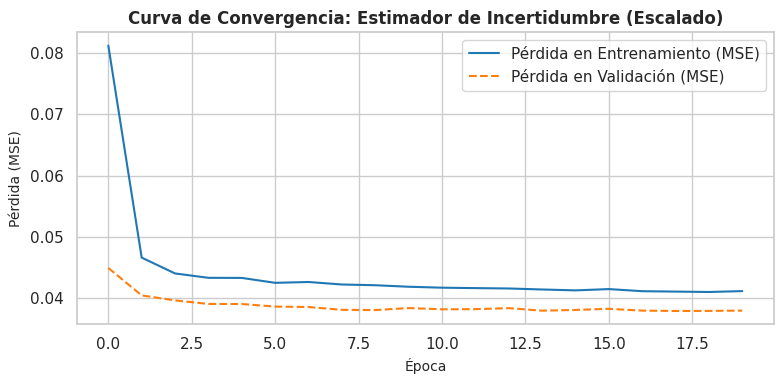

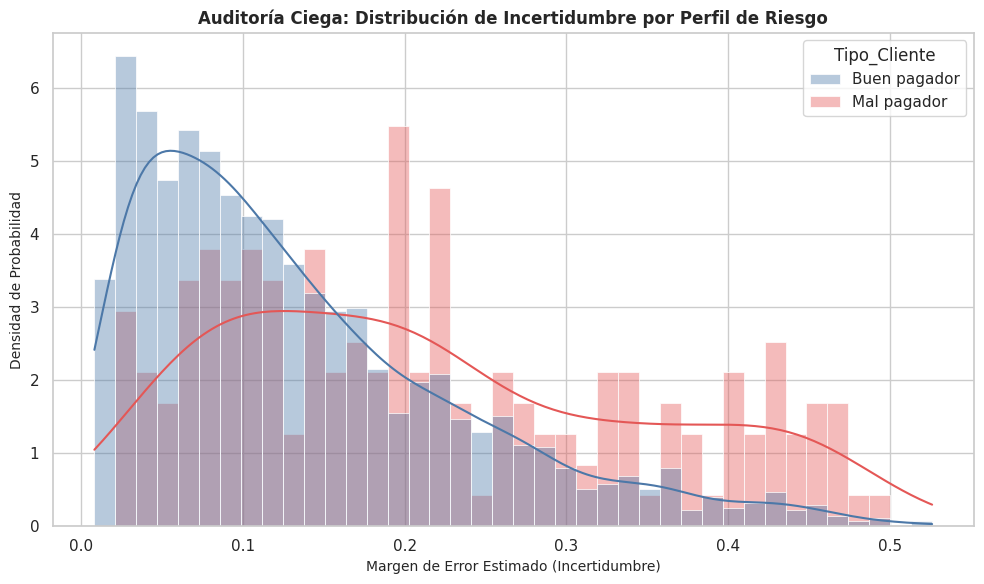

In [10]:
uncertainty_training_path = ARTIFACTS / "uncertainty_training_curves.png"
uncertainty_distribution_path = ARTIFACTS / "uncertainty_distribution.png"

if uncertainty_training_path.exists():
    display(NotebookImage(filename=str(uncertainty_training_path)))
else:
    print(f"No se encontr? {uncertainty_training_path}")

if uncertainty_distribution_path.exists():
    display(NotebookImage(filename=str(uncertainty_distribution_path)))
else:
    print(f"No se encontr? {uncertainty_distribution_path}")

## 9. Disclaimer sobre la variable sensible y comparaci?n con la recomendaci?n del curso

En este proyecto, `CODE_GENDER` se mantiene por defecto **fuera de las features de entrada**. La variable sensible viaja como `s` dentro de `y_true` extendido para que la FAIR loss pueda penalizar dependencia entre `?` y `s`, pero el modelo principal no recibe directamente el g?nero como predictor.

Esta decisi?n es deliberada y conservadora: evita que el modelo use expl?citamente la variable sensible. La recomendaci?n habitual del curso puede plantear la alternativa de incluir la variable sensible como entrada y forzar independencia en la salida mediante la penalizaci?n FAIR. Esa alternativa tiene una ventaja t?cnica: la red puede aprender a corregir dependencias condicionadas observando el atributo sensible. Tambi?n tiene un coste operativo: exige aceptar que el atributo sensible entra al sistema de scoring.

La comparaci?n queda as?:

| Enfoque | G?nero entra en `X` | Ventaja | Riesgo / l?mite |
|---|---:|---|---|
| Implementaci?n de este notebook | No | Garant?a directa de que el modelo no usa g?nero como feature | Pueden quedar proxies indirectos en otras variables |
| Recomendaci?n alternativa del curso | S? | Permite penalizar y corregir dependencia observando el atributo sensible | Requiere gobernanza estricta del uso de una variable sensible |

Por tanto, el resultado debe interpretarse como una reducci?n de dependencia bajo una m?trica concreta (`Pearson?` sobre predicciones y `CODE_GENDER`), no como una certificaci?n completa de ausencia de sesgo. La equidad real requiere auditor?as adicionales por subgrupo, estabilidad temporal y revisi?n de proxies.